In [ ]:
import numpy as np
import matplotlib as mtp
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
from matplotlib.ticker import FormatStrFormatter
from scipy import stats
from scipy.constants import g
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import StrMethodFormatter



In [ ]:
from google.colab import drive
import sys
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/Libreria python')
import analisi_dati as ad

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Raccolta dati glicerina.xlsx to Raccolta dati glicerina.xlsx


Misure del diametro delle palline da 3 mm

In [ ]:
df=pd.read_excel("Raccolta dati glicerina.xlsx", sheet_name=0)
df=df.fillna('')
df.round(2)

,Unnamed: 0,Diametro 1 (mm),Diametro 2 (mm),Diametro 3 (mm),Diametro 4 (mm),Diametro 5 (mm),Diametro 6 (mm),Diametro 7 (mm),Diametro 8 (mm),Diametro 9 (mm),Diametro 10 (mm),Diametro medio
0,,2.99,3.00,3.00,3,3,3.00,3.00,2.99,3.00,3.00,
1,,3.00,3.00,3.00,3,3,2.99,3.00,2.99,2.99,3.00,
2,,2.99,2.99,2.99,3,3,3.00,2.99,2.99,3.01,2.99,
3,Media,2.99,3.00,3.00,3,3,3.00,3.00,2.99,3.00,3.00,2.996667
4,Deviazione standard,0.01,0.01,0.01,0,0,0.01,0.01,0.00,0.01,0.01,0.003143


Le misure presentano un errore compatibile con la precisione del calibro (0,01m)

Misure di massa delle palline da 3 mm

In [ ]:
df1=pd.read_excel("Raccolta dati glicerina.xlsx", sheet_name="Massa palline")
df1.fillna('')
df1.round(4)


,Unnamed: 0,Massa 1 (g),Massa 2 (g),Massa 3 (g),Massa 4 (g),Massa 5 (g),Massa 10 palline (g),Massa 10 palline/10 (g)
0,Misurazione 1,0.1101,0.1101,0.1102,0.1100,0.1099,1.1008,0.1101
1,Misurazione 2,0.1102,0.1102,0.1101,0.1101,0.1098,1.1003,0.1100
2,Misurazione 3,0.1101,0.1101,0.1101,0.1103,0.1101,1.1002,0.1100
3,Media,0.1101,0.1101,0.1101,0.1101,0.1099,1.1004,0.1100
4,Deviazione standard,0.0001,0.0001,0.0001,0.0002,0.0002,0.0003,0.0000


Le misure presentano un errore compatibile con la precisione della bilancia (0,0001 g)

Misura dei tempi di caduta e calcolo della velocità media.

In [ ]:
df2=pd.read_excel("Raccolta dati glicerina.xlsx", sheet_name=2)
df2=df2.round(2)
df2


,Unnamed: 0,Tempi caduta (s)
0,1,4.09
1,2,4.15
2,3,3.86
3,4,3.92
4,5,4.00
...,...,...
100,Media,3.96
101,Deviazione standard,0.21
102,Errore standard media,0.02
103,Velocità limite,25.26


Le misurazioni sono state effettutate in due momenti diversi. Le prime 63 al mattino, le restanti al pomeriggio. Non si è però registrata una significativa variazione di temperatura dell'ambiente, che si è sempre aggirata attorno ai 21,5°C. Si osserva quindi una certa uniformità nelle misure


Istogramma e funzione di Gauss associata ai dati

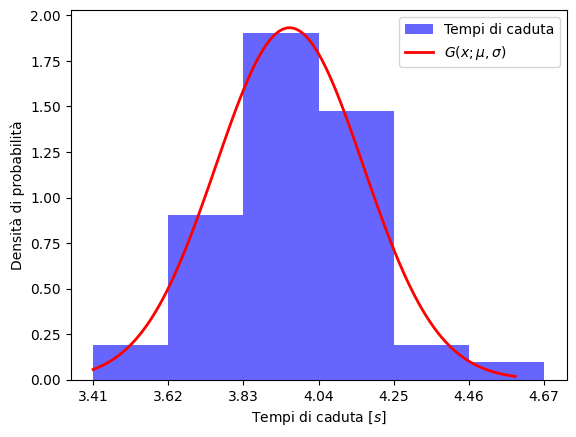

In [ ]:
#Istogramma dei tempi di caduta#
tempi = df2.iloc[:-5, 1]
array = pd.to_numeric(tempi, errors='coerce').dropna().values
plt.hist(array, [min(array), 3.62, 3.83, 4.04, 4.25, 4.46, 4.67], density=True, alpha=0.6, color='b', label='Tempi di caduta')
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.xticks([min(array), 3.62, 3.83, 4.04, 4.25, 4.46, 4.67])
#Funzione di densità di probabilità di Gauss associata alle misure effettuate#
m=np.mean(array)
s=np.std(array)
def gauss(x, m, s):
    return 1/(s * np.sqrt(2 * np.pi)) * np.exp(-(x - m)**2 / (2 * s**2))
t = np.linspace(min(array), max(array), 110)
plt.plot(t, gauss(t, m, s), 'r-', lw=2, label=r"$G(x;\mu,\sigma)$")
plt.xlabel(r'Tempi di caduta [$s$]')
plt.ylabel(r'Densità di probabilità')


plt.legend()
plt.show()

L'istogramma non mostra evidenti errori sistematici

In [ ]:
#Ricavo la frequenza dei bins dell'istogramma#
osservati, _ = np.histogram(array, bins=[min(array), 3.62, 3.83, 4.04, 4.25, 4.46, 4.67])
osservati = osservati.astype(float)
#Ricavo il valore di aspettazione delle frequenze#
cdf_values = stats.norm.cdf([min(array), 3.62, 3.83, 4.04, 4.25, 4.46, 4.67], loc=m, scale=s)
probabilita_bin = np.diff(cdf_values)
# Normalizzo le probabilità in modo che la loro somma sia 1 e poi moltiplico per il numero totale di osservazioni.
# Questo assicura che la somma degli attesi sia uguale alla somma degli osservati.
attesi = (probabilita_bin / np.sum(probabilita_bin)) * len(array)
#Eseguo il test del Chi-quadro con 3 gradi di libertà persi#
chi_stat, p_value = stats.chisquare(f_obs=osservati, f_exp=attesi, ddof=2)
print("Chi-quadro ridotto:", chi_stat/3)
print("p-value:", p_value)

Chi-quadro ridotto: 1.5527867613577377
p-value: 0.19859243908907784


Test del chi quadro di adattamento tra l'istogramma e una distribuzione di probabilità di Gauss

Tempi di caduta di palline di varie dimensioni su una lunghezza di 20 cm. Nella propagazione degli errori sulla velocità è stato considerata un incertezza di 3 mm sulla misura dei 20 cm, dovuta alla sensibilità del metro a nastro e eventuali errori di allineamento.

In [ ]:
df3=pd.read_excel("Raccolta dati glicerina.xlsx", sheet_name=3)
df3.round(2)

,Unnamed: 0,2mm,3mm,4mm,5mm,6mm
0,1,17.07,8.01,4.65,3.09,2.37
1,2,16.44,7.95,4.68,3.16,2.50
2,3,16.98,7.97,4.69,3.00,2.52
3,4,17.25,7.85,4.52,3.11,2.40
4,5,16.85,7.86,4.70,3.03,2.16
5,6,17.18,8.15,4.85,3.10,2.22
6,7,16.87,8.26,4.66,3.25,2.33
7,8,16.91,7.66,4.70,2.91,2.35
8,9,17.03,7.92,4.68,3.02,2.44
9,10,16.94,7.92,4.73,2.90,2.50


Dipendenze della velocità limite da $r$ e $r^2$, scala logaritmica

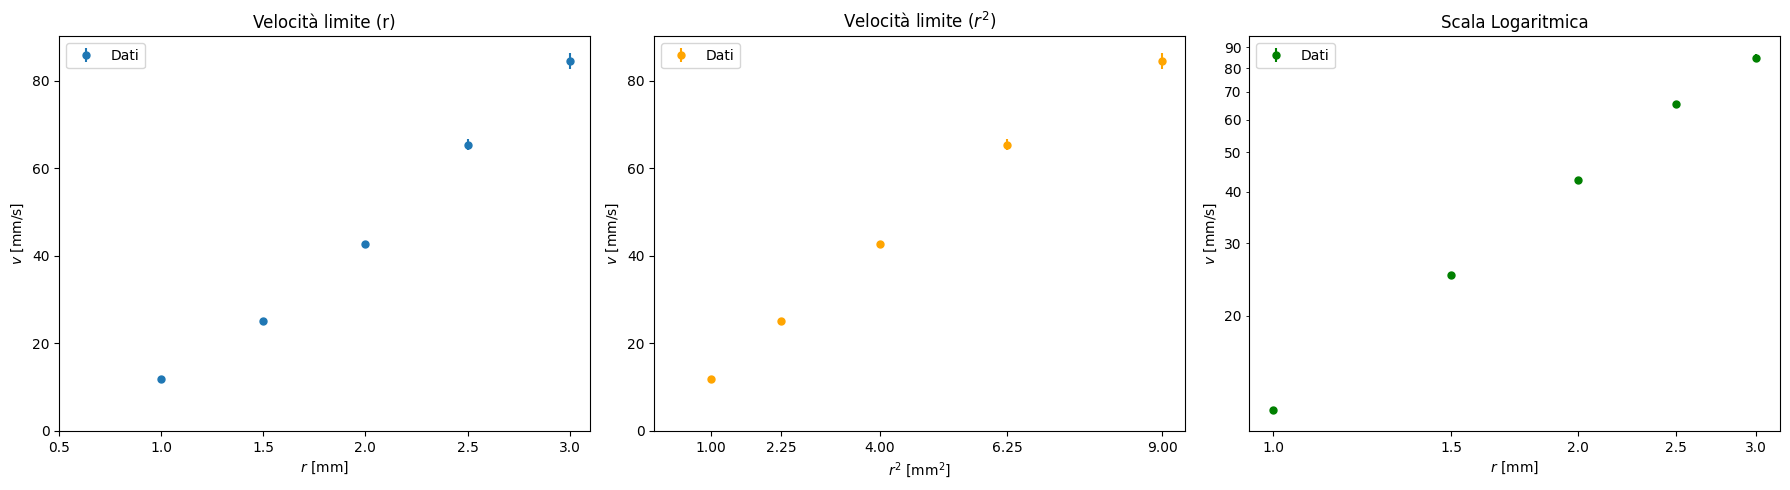

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

velocità = df3.iloc[13]
v = pd.to_numeric(velocità, errors='coerce').dropna().values
d = np.array([2, 3, 4, 5, 6])
s_v = df3.iloc[14]
sv = pd.to_numeric(s_v, errors='coerce').dropna().values
r = d / 2

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].errorbar(r, v, yerr=sv, fmt='o', ls='none', label='Dati', ms=5)
axs[0].set_xlim(left=0.5)
axs[0].set_ylim(bottom=0)
axs[0].set_xlabel(r'$r$ [mm]')
axs[0].set_ylabel(r'$v$ [mm/s]')
axs[0].set_title('Velocità limite (r)')
axs[0].legend()

axs[1].errorbar(r*r, v, yerr=sv, fmt='o', ls='none', label='Dati', ms=5, color='orange')
axs[1].set_xlim(left=0)
axs[1].set_ylim(bottom=0)
axs[1].set_xticks(r*r)
axs[1].set_xlabel(r'$r^2$ [mm$^2$]')
axs[1].set_ylabel(r'$v$ [mm/s]')
axs[1].set_title('Velocità limite ($r^2$)')
axs[1].legend()

axs[2].errorbar(r, v, yerr=sv, fmt='o', ls='none', label='Dati', ms=5, color='green')
axs[2].set_xscale('log')
axs[2].set_yscale('log')
axs[2].set_xticks(r)
axs[2].xaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
axs[2].yaxis.set_major_formatter(ScalarFormatter())
axs[2].yaxis.set_minor_formatter(ScalarFormatter())
axs[2].set_xlabel(r'$r$ [mm]')
axs[2].set_ylabel(r'$v$ [mm/s]')
axs[2].set_title('Scala Logaritmica')
axs[2].legend()
plt.tight_layout()
plt.show()

Minimi quadrati pesati per una retta passante per l'origine

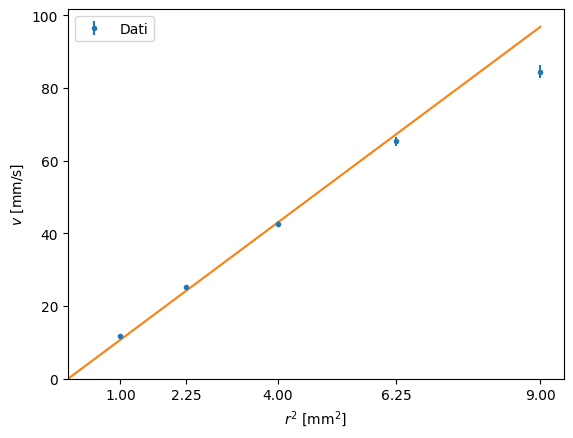

10.762861892834392 0.08345314963537397


In [ ]:
def minquadpesati(x, y, sy):
    if len(x) != len(y) or len(x) != len(sy) or len(x) == 0:
        return None
    sumxyw = 0
    sumx2w = 0
    for i in range(len(x)):
        w = 1 / (sy[i]**2)
        sumxyw += x[i] * y[i] * w
        sumx2w += x[i] * x[i] * w
    k = sumxyw / sumx2w
    sk = 1 / np.sqrt(sumx2w)
    return (k, sk)

d = np.array([2, 3, 4, 5, 6])
r = d / 2
x = r * r
y = v
sy = sv

k, sk = minquadpesati(x, y, sy)

def retta(x, k):
    return k * x

t = np.linspace(0, max(x), 100)

plt.errorbar(x, v, yerr=sv, fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k))

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.xticks([1, 2.25, 4, 6.25, 9])
plt.yticks([0, 20, 40, 60, 80, 100])
plt.xlabel(r'$r^2$ [mm$^2$]')
plt.ylabel(r'$v$ [mm/s]')
plt.legend()
plt.show()
print(k, sk)



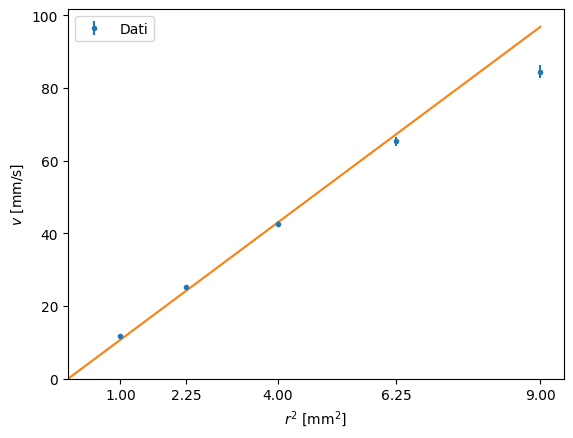

10.762861892834392 0.08345314963537397


In [ ]:
d = np.array([2, 3, 4, 5, 6])
r = d / 2
x = r * r
y = v
sy = sv
k, sk=ad.minquadw_kx(x, y, sy)

def retta(x, k):
    return k * x

t = np.linspace(0, max(x), 100)

plt.errorbar(x, v, yerr=sv, fmt='o', ls='none', label='Dati', ms=3)
plt.plot(t, retta(t, k))

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.xticks([1, 2.25, 4, 6.25, 9])
plt.yticks([0, 20, 40, 60, 80, 100])
plt.xlabel(r'$r^2$ [mm$^2$]')
plt.ylabel(r'$v$ [mm/s]')
plt.legend()
plt.show()
print(k, sk)



In [ ]:
e=k*(r**2)
y=v
ndof=len(x)-1
def chiquadro(e, k, y, sy):
  if len(e) != len(y) or len(e) != len(sy) or len(e) == 0:
   return 'None'
  chi2=0
  for i in range(len(e)):
    sy_2=sy[i]**2
    o=y[i]
    exp=e[i]
    chi2+=(o-exp)**2/(sy_2)
  return chi2
print(chiquadro(e, k, y, sy)/ndof)

20.844952875684307


In [ ]:
chi2, ndof, chi2_rid, p_value =ad.chi_quadro(y, e, sy, n_parametri=1)
print(chi2_rid, p_value)

20.844952875684314 3.3467955056299385e-17


Il test del chi quadrato evidenzia la presenza di errori sistematici considerevoli.

Misurare la densità delle palline da 3mm che useremo per misurare la densità della glicerina. Usiamo la media delle masse e dei diametri misurati all'inizio dell'esperienza.


In [ ]:
#Calcolo della densità delle palline da 3mm#
D=10**6*(0.1100/((4/3)*np.pi*(2.99667/2)**3))
sD=D*np.sqrt((0.000032/0.11)**2+9*((0.0032)/2.99667)**2)
print(D, sD)


7806.876381406949 25.11267038966654


In [ ]:
#Calcolo densità aria
P=(1.2926/(1+0.003661*21.5))*757.56/760
sP=P*np.sqrt((0.5/21.5)**2+(0.0000075/757.56)**2)
print(P, sP)

1.1944343540271987 0.027777543116914112


In [ ]:
#Calcolo densità glicerina
Ma= 50.0268*10**(-3) #massa del pescante in aria [kg]
Mg= 24.883*10**(-3) #massa del pescante nella glicerina [kg]
Vp= 2.0*10**(-5) #volume del pescante in aria [m**3]
Dg=P+(Ma-Mg)/Vp #densità della glicerina [kg/m**3]
sDg=np.sqrt((sP**2+((0.0005)**2+(0.0001)**2)/Vp**2))
print(Dg, sDg)

1258.3844343540272 25.495112700121595


In [ ]:
#Calcolo coefficiente di viscosità della glicerina
η=(2*g*(D-Dg))/(9*k*10**3)
sη=η*np.sqrt((sk/k)**2+((sDg)**2+(sD)**2)/(D-Dg)**2)
print(η, sη)

1.3259333435865246 0.012577890528427064


In [ ]:
eta_teorico=np.exp(-2.18-0.099*21.5)*100
t=np.abs(η-eta_teorico)/sη
print(t)

1.5454229199610603
